In [1]:
import torch
print(torch.__version__)          
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))  

2.7.1+cu118
True
NVIDIA GeForce RTX 2050


In [2]:
import pandas as pd
from datasets import load_dataset

In [3]:
train_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")

train_df = train_data.to_pandas()
val_df = val_data.to_pandas()
test_df = test_data.to_pandas()

print("Sample data (first 5 rows):")
print(train_df.head())

Sample data (first 5 rows):
                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  disgust  fear  joy  sadness  surprise  
0      0      NaN     1    0        0         1  
1      0      NaN     2    0        0         0  
2      0      NaN     1    0        3         0  
3      0      NaN     0    0        0         0  
4      0      NaN     3    0        1         2  


In [4]:
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]

def convert_two_step_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1️⃣ Drop disgust
    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])
    
    for e in EMOTIONS:
        df[f"{e}_intensity"] = df[e].copy()

    for e in EMOTIONS:
        df[e] = (df[e] > 0).astype(int)

    return df

train_two = convert_two_step_labels(train_df)
val_two = convert_two_step_labels(val_df)    
test_two = convert_two_step_labels(test_df)
print(train_two.head())


                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  fear  joy  sadness  surprise  anger_intensity  fear_intensity  \
0      0     1    0        0         1                0               1   
1      0     1    0        0         0                0               2   
2      0     1    0        1         0                0               1   
3      0     0    0        0         0                0               0   
4      0     1    0        1         1                0               3   

   joy_intensity  sadness_intensity  surprise_intensity  
0   

In [5]:
train_presence = train_two[EMOTIONS].sum()
val_presence   = val_two[EMOTIONS].sum()
test_presence  = test_two[EMOTIONS].sum()

print("Train Presence Distribution:\n", train_presence)
print("\nValidation Presence Distribution:\n", val_presence)
print("\nTest Presence Distribution:\n", test_presence)

Train Presence Distribution:
 anger        333
fear        1610
joy          674
sadness      875
surprise     839
dtype: int64

Validation Presence Distribution:
 anger       16
fear        62
joy         31
sadness     34
surprise    31
dtype: int64

Test Presence Distribution:
 anger        322
fear        1543
joy          670
sadness      880
surprise     799
dtype: int64


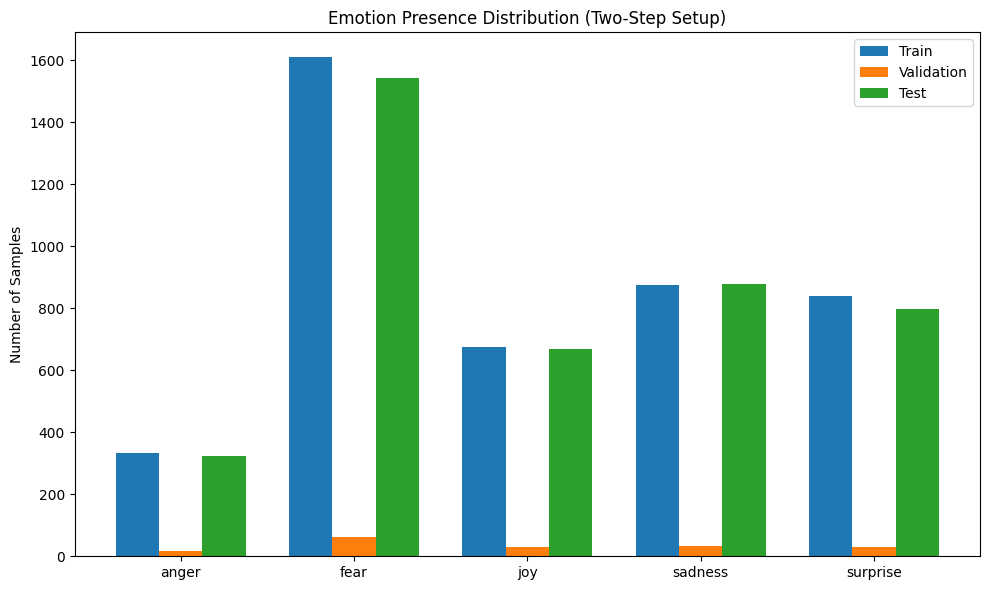

In [6]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(EMOTIONS))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, train_presence, width, label="Train")
plt.bar(x, val_presence, width, label="Validation")
plt.bar(x + width, test_presence, width, label="Test")

plt.xticks(x, EMOTIONS)
plt.ylabel("Number of Samples")
plt.title("Emotion Presence Distribution (Two-Step Setup)")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
def get_intensity_counts(df):
    intensity_cols = [f"{e}_intensity" for e in EMOTIONS]
    intensities = pd.concat([df[col] for col in intensity_cols])
    return intensities.value_counts().sort_index()

train_intensity = get_intensity_counts(train_two)
val_intensity   = get_intensity_counts(val_two)
test_intensity  = get_intensity_counts(test_two)
print("Train Intensity Distribution:\n", train_intensity)
print("\nValidation Intensity Distribution:\n", val_intensity)  
print("\nTest Intensity Distribution:\n", test_intensity)

Train Intensity Distribution:
 0    9484
1    2605
2    1256
3     470
Name: count, dtype: int64

Validation Intensity Distribution:
 0    401
1    102
2     59
3     13
Name: count, dtype: int64

Test Intensity Distribution:
 0    9611
1    2535
2    1192
3     487
Name: count, dtype: int64


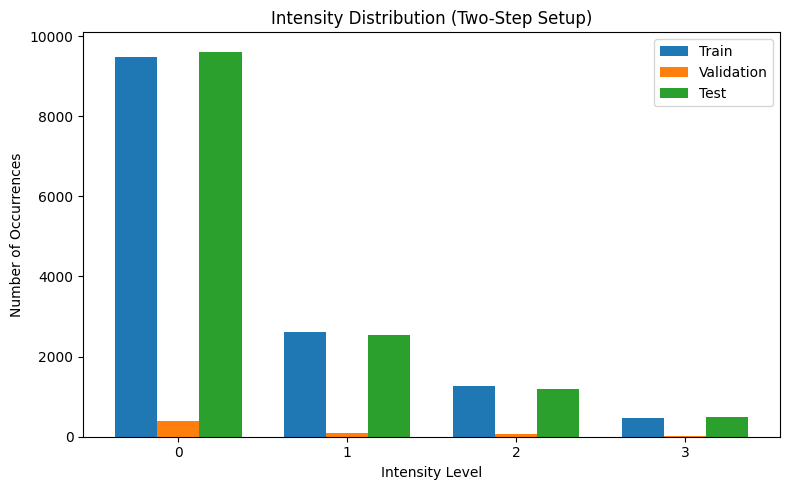

In [8]:
levels = [0,1,2,3]
x = np.arange(len(levels))

plt.figure(figsize=(8,5))

plt.bar(x - width, train_intensity.reindex(levels, fill_value=0), width, label="Train")
plt.bar(x, val_intensity.reindex(levels, fill_value=0), width, label="Validation")
plt.bar(x + width, test_intensity.reindex(levels, fill_value=0), width, label="Test")

plt.xticks(x, levels)
plt.xlabel("Intensity Level")
plt.ylabel("Number of Occurrences")
plt.title("Intensity Distribution (Two-Step Setup)")
plt.legend()
plt.tight_layout()
plt.show()

Current sizes: {'train': 2763, 'val': 115, 'test': 2765}
Target sizes : {'train': 3950, 'val': 1129, 'test': 564}
New sizes: {'train': 2763, 'val': 2316, 'test': 564}
New ratios: {'train': 0.48963317384370014, 'val': 0.4104199893673578, 'test': 0.09994683678894205}


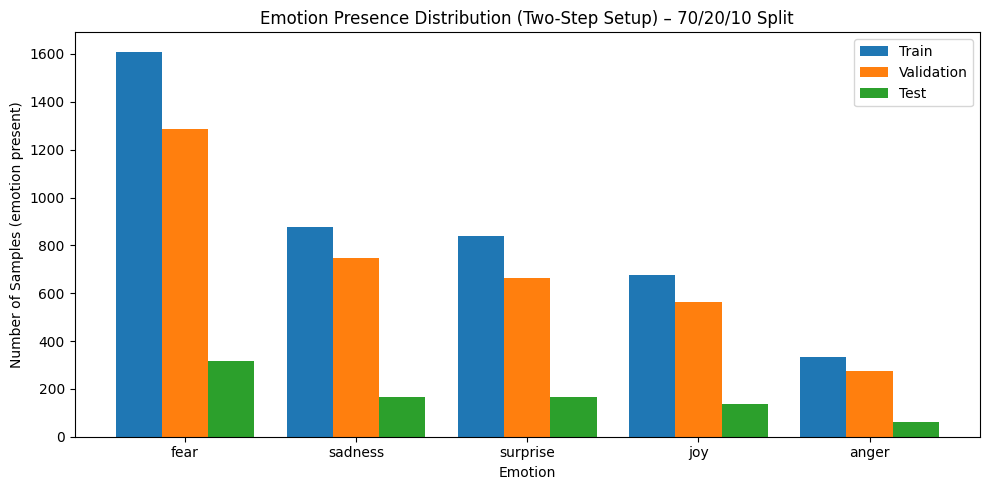

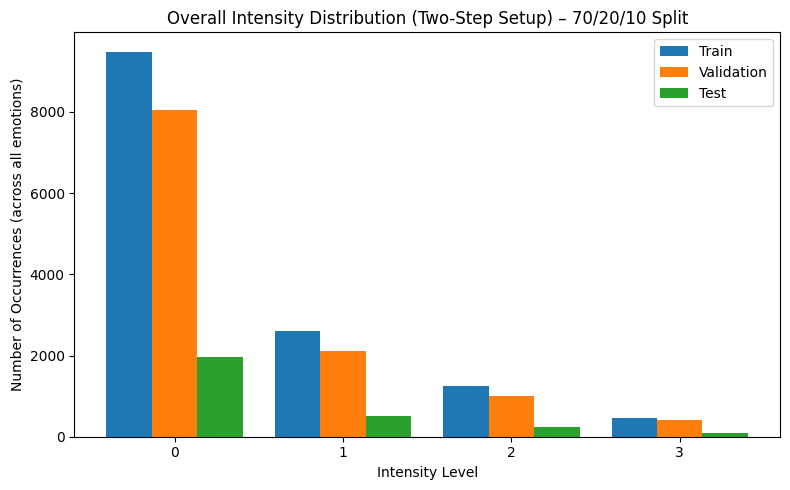

Current sizes: {'train': 2763, 'val': 115, 'test': 2765}
Target sizes : {'train': 3950, 'val': 1129, 'test': 564}
New sizes: {'train': 2763, 'val': 2316, 'test': 564}
New ratios: {'train': 0.48963317384370014, 'val': 0.4104199893673578, 'test': 0.09994683678894205}


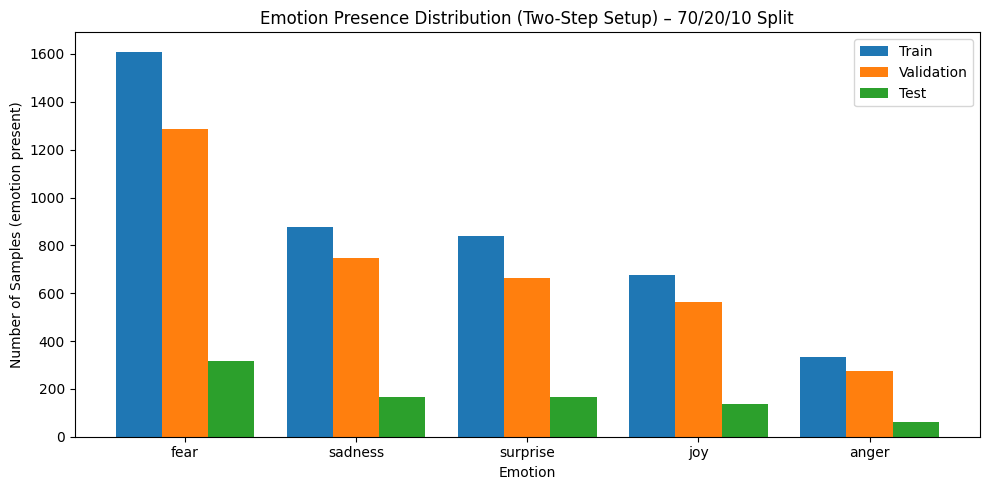

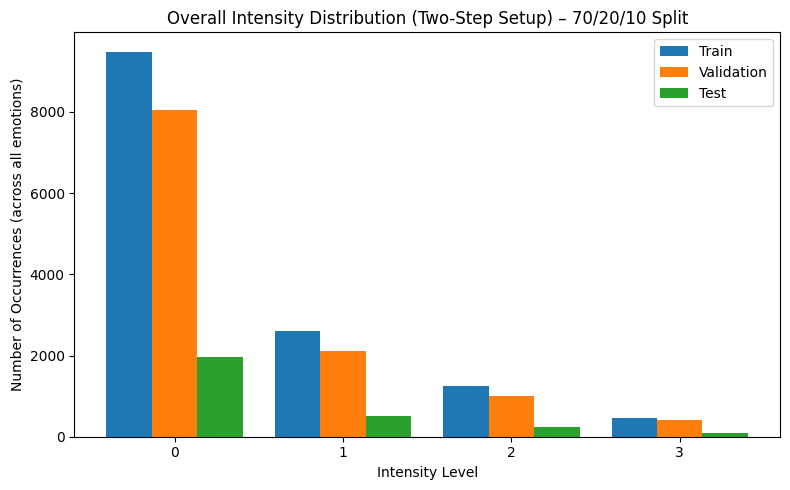

Current sizes: {'train': 2763, 'val': 115, 'test': 2765}
Target sizes : {'train': 3950, 'val': 1129, 'test': 564}
New sizes: {'train': 2763, 'val': 2316, 'test': 564}
New ratios: {'train': 0.48963317384370014, 'val': 0.4104199893673578, 'test': 0.09994683678894205}


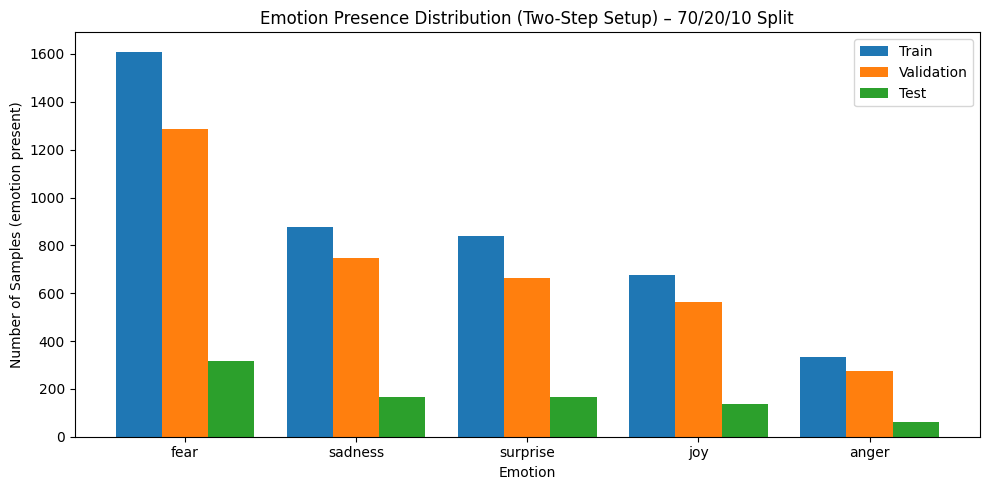

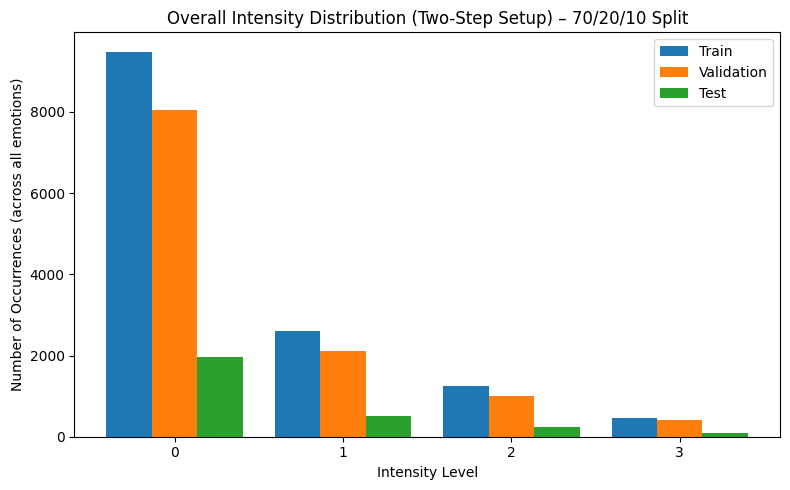

In [11]:
SEED = 42

def rebalance_val_test_70_20_10(train_df, val_df, test_df, seed=42):
    n_train, n_val, n_test = len(train_df), len(val_df), len(test_df)
    n_total = n_train + n_val + n_test

    target_train = int(round(0.70 * n_total))
    target_val   = int(round(0.20 * n_total))
    target_test  = n_total - target_train - target_val

    print("Current sizes:", {"train": n_train, "val": n_val, "test": n_test})
    print("Target sizes :", {"train": target_train, "val": target_val, "test": target_test})

    combined = pd.concat([val_df, test_df], ignore_index=True)
    rng = np.random.default_rng(seed)
    combined = combined.iloc[rng.permutation(len(combined))].reset_index(drop=True)

    combined_size = len(combined)
    new_test_size = target_test
    if new_test_size < 0 or new_test_size > combined_size:
        raise ValueError("Target test size is not feasible. Check current split sizes.")

    new_val_size = combined_size - new_test_size
    new_val_df  = combined.iloc[:new_val_size].reset_index(drop=True)
    new_test_df = combined.iloc[new_val_size:].reset_index(drop=True)

    print("New sizes:", {"train": len(train_df), "val": len(new_val_df), "test": len(new_test_df)})
    print("New ratios:", {
        "train": len(train_df)/n_total,
        "val": len(new_val_df)/n_total,
        "test": len(new_test_df)/n_total
    })

    return train_df, new_val_df, new_test_df

train_two_70, val_two_20, test_two_10 = rebalance_val_test_70_20_10(
    train_two, val_two, test_two, seed=SEED
)

# ----------------------------
# 3A) Plot emotion presence distribution (Step 1 of two-step)
#     (Train/Val/Test together in one plot)
# ----------------------------
def plot_presence_distribution(train_df, val_df, test_df, title):
    train_counts = train_df[EMOTIONS].sum()
    val_counts   = val_df[EMOTIONS].sum()
    test_counts  = test_df[EMOTIONS].sum()

    # Keep emotion order or sort by total
    total = (train_counts + val_counts + test_counts).sort_values(ascending=False)
    emotions_sorted = total.index.tolist()

    train_counts = train_counts[emotions_sorted]
    val_counts   = val_counts[emotions_sorted]
    test_counts  = test_counts[emotions_sorted]

    x = np.arange(len(emotions_sorted))
    width = 0.27

    plt.figure(figsize=(10, 5))
    plt.bar(x - width, train_counts.values, width, label="Train")
    plt.bar(x,         val_counts.values,   width, label="Validation")
    plt.bar(x + width, test_counts.values,  width, label="Test")

    plt.xticks(x, emotions_sorted)
    plt.xlabel("Emotion")
    plt.ylabel("Number of Samples (emotion present)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_presence_distribution(
    train_two_70, val_two_20, test_two_10,
    "Emotion Presence Distribution (Two-Step Setup) – 70/20/10 Split"
)

# ----------------------------
# 3B) Plot intensity distribution (Step 2 of two-step)
#     Option 1: overall across all emotions, grouped by split
# ----------------------------
def intensity_counts_overall(df):
    intensity_cols = [f"{e}_intensity" for e in EMOTIONS]
    # stack all intensities into one Series
    all_int = pd.concat([df[c] for c in intensity_cols], ignore_index=True)
    return all_int.value_counts().sort_index()

def plot_intensity_distribution_overall(train_df, val_df, test_df, title):
    train_c = intensity_counts_overall(train_df)
    val_c   = intensity_counts_overall(val_df)
    test_c  = intensity_counts_overall(test_df)

    levels = [0, 1, 2, 3]
    train_c = train_c.reindex(levels, fill_value=0)
    val_c   = val_c.reindex(levels, fill_value=0)
    test_c  = test_c.reindex(levels, fill_value=0)

    x = np.arange(len(levels))
    width = 0.27

    plt.figure(figsize=(8, 5))
    plt.bar(x - width, train_c.values, width, label="Train")
    plt.bar(x,         val_c.values,   width, label="Validation")
    plt.bar(x + width, test_c.values,  width, label="Test")

    plt.xticks(x, levels)
    plt.xlabel("Intensity Level")
    plt.ylabel("Number of Occurrences (across all emotions)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_intensity_distribution_overall(
    train_two_70, val_two_20, test_two_10,
    "Overall Intensity Distribution (Two-Step Setup) – 70/20/10 Split"
)

# ----------------------------
# Optional: intensity distribution per emotion (one plot per emotion)
# ----------------------------
def plot_intensity_per_emotion(train_df, val_df, test_df, emotion):
    col = f"{emotion}_intensity"
    train_c = train_df[col].value_counts().sort_index()
    val_c   = val_df[col].value_counts().sort_index()
    test_c  = test_df[col].value_counts().sort_index()

    levels = [0, 1, 2, 3]
    train_c = train_c.reindex(levels, fill_value=0)
    val_c   = val_c.reindex(levels, fill_value=0)
    test_c  = test_c.reindex(levels, fill_value=0)

    x = np.arange(len(levels))
    width = 0.27

    plt.figure(figsize=(8, 4))
    plt.bar(x - width, train_c.values, width, label="Train")
    plt.bar(x,         val_c.values,   width, label="Validation")
    plt.bar(x + width, test_c.values,  width, label="Test")

    plt.xticks(x, levels)
    plt.xlabel("Intensity Level")
    plt.ylabel("Number of Samples")
    plt.title(f"{emotion.capitalize()} Intensity Distribution – 70/20/10 Split")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example:
# for e in EMOTIONS:
#     plot_intensity_per_emotion(train_two_70, val_two_20, test_two_10, e)
def rebalance_val_test_70_20_10(train_df, val_df, test_df, seed=42):
    n_train, n_val, n_test = len(train_df), len(val_df), len(test_df)
    n_total = n_train + n_val + n_test

    target_train = int(round(0.70 * n_total))
    target_val   = int(round(0.20 * n_total))
    target_test  = n_total - target_train - target_val

    print("Current sizes:", {"train": n_train, "val": n_val, "test": n_test})
    print("Target sizes :", {"train": target_train, "val": target_val, "test": target_test})

    combined = pd.concat([val_df, test_df], ignore_index=True)
    rng = np.random.default_rng(seed)
    combined = combined.iloc[rng.permutation(len(combined))].reset_index(drop=True)

    combined_size = len(combined)
    new_test_size = target_test
    if new_test_size < 0 or new_test_size > combined_size:
        raise ValueError("Target test size is not feasible. Check current split sizes.")

    new_val_size = combined_size - new_test_size
    new_val_df  = combined.iloc[:new_val_size].reset_index(drop=True)
    new_test_df = combined.iloc[new_val_size:].reset_index(drop=True)

    print("New sizes:", {"train": len(train_df), "val": len(new_val_df), "test": len(new_test_df)})
    print("New ratios:", {
        "train": len(train_df)/n_total,
        "val": len(new_val_df)/n_total,
        "test": len(new_test_df)/n_total
    })

    return train_df, new_val_df, new_test_df

train_two_70, val_two_20, test_two_10 = rebalance_val_test_70_20_10(
    train_two, val_two, test_two, seed=SEED
)

# ----------------------------
# 3A) Plot emotion presence distribution (Step 1 of two-step)
#     (Train/Val/Test together in one plot)
# ----------------------------
def plot_presence_distribution(train_df, val_df, test_df, title):
    train_counts = train_df[EMOTIONS].sum()
    val_counts   = val_df[EMOTIONS].sum()
    test_counts  = test_df[EMOTIONS].sum()

    # Keep emotion order or sort by total
    total = (train_counts + val_counts + test_counts).sort_values(ascending=False)
    emotions_sorted = total.index.tolist()

    train_counts = train_counts[emotions_sorted]
    val_counts   = val_counts[emotions_sorted]
    test_counts  = test_counts[emotions_sorted]

    x = np.arange(len(emotions_sorted))
    width = 0.27

    plt.figure(figsize=(10, 5))
    plt.bar(x - width, train_counts.values, width, label="Train")
    plt.bar(x,         val_counts.values,   width, label="Validation")
    plt.bar(x + width, test_counts.values,  width, label="Test")

    plt.xticks(x, emotions_sorted)
    plt.xlabel("Emotion")
    plt.ylabel("Number of Samples (emotion present)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_presence_distribution(
    train_two_70, val_two_20, test_two_10,
    "Emotion Presence Distribution (Two-Step Setup) – 70/20/10 Split"
)

# ----------------------------
# 3B) Plot intensity distribution (Step 2 of two-step)
#     Option 1: overall across all emotions, grouped by split
# ----------------------------
def intensity_counts_overall(df):
    intensity_cols = [f"{e}_intensity" for e in EMOTIONS]
    # stack all intensities into one Series
    all_int = pd.concat([df[c] for c in intensity_cols], ignore_index=True)
    return all_int.value_counts().sort_index()

def plot_intensity_distribution_overall(train_df, val_df, test_df, title):
    train_c = intensity_counts_overall(train_df)
    val_c   = intensity_counts_overall(val_df)
    test_c  = intensity_counts_overall(test_df)

    levels = [0, 1, 2, 3]
    train_c = train_c.reindex(levels, fill_value=0)
    val_c   = val_c.reindex(levels, fill_value=0)
    test_c  = test_c.reindex(levels, fill_value=0)

    x = np.arange(len(levels))
    width = 0.27

    plt.figure(figsize=(8, 5))
    plt.bar(x - width, train_c.values, width, label="Train")
    plt.bar(x,         val_c.values,   width, label="Validation")
    plt.bar(x + width, test_c.values,  width, label="Test")

    plt.xticks(x, levels)
    plt.xlabel("Intensity Level")
    plt.ylabel("Number of Occurrences (across all emotions)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_intensity_distribution_overall(
    train_two_70, val_two_20, test_two_10,
    "Overall Intensity Distribution (Two-Step Setup) – 70/20/10 Split"
)

# ----------------------------
# Optional: intensity distribution per emotion (one plot per emotion)
# ----------------------------
def plot_intensity_per_emotion(train_df, val_df, test_df, emotion):
    col = f"{emotion}_intensity"
    train_c = train_df[col].value_counts().sort_index()
    val_c   = val_df[col].value_counts().sort_index()
    test_c  = test_df[col].value_counts().sort_index()

    levels = [0, 1, 2, 3]
    train_c = train_c.reindex(levels, fill_value=0)
    val_c   = val_c.reindex(levels, fill_value=0)
    test_c  = test_c.reindex(levels, fill_value=0)

    x = np.arange(len(levels))
    width = 0.27

    plt.figure(figsize=(8, 4))
    plt.bar(x - width, train_c.values, width, label="Train")
    plt.bar(x,         val_c.values,   width, label="Validation")
    plt.bar(x + width, test_c.values,  width, label="Test")

    plt.xticks(x, levels)
    plt.xlabel("Intensity Level")
    plt.ylabel("Number of Samples")
    plt.title(f"{emotion.capitalize()} Intensity Distribution – 70/20/10 Split")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example:
# for e in EMOTIONS:
#     plot_intensity_per_emotion(train_two_70, val_two_20, test_two_10, e)

def rebalance_val_test_70_20_10(train_df, val_df, test_df, seed=42):
    n_train, n_val, n_test = len(train_df), len(val_df), len(test_df)
    n_total = n_train + n_val + n_test

    target_train = int(round(0.70 * n_total))
    target_val   = int(round(0.20 * n_total))
    target_test  = n_total - target_train - target_val

    print("Current sizes:", {"train": n_train, "val": n_val, "test": n_test})
    print("Target sizes :", {"train": target_train, "val": target_val, "test": target_test})

    combined = pd.concat([val_df, test_df], ignore_index=True)
    rng = np.random.default_rng(seed)
    combined = combined.iloc[rng.permutation(len(combined))].reset_index(drop=True)

    combined_size = len(combined)
    new_test_size = target_test
    if new_test_size < 0 or new_test_size > combined_size:
        raise ValueError("Target test size is not feasible. Check current split sizes.")

    new_val_size = combined_size - new_test_size
    new_val_df  = combined.iloc[:new_val_size].reset_index(drop=True)
    new_test_df = combined.iloc[new_val_size:].reset_index(drop=True)

    print("New sizes:", {"train": len(train_df), "val": len(new_val_df), "test": len(new_test_df)})
    print("New ratios:", {
        "train": len(train_df)/n_total,
        "val": len(new_val_df)/n_total,
        "test": len(new_test_df)/n_total
    })

    return train_df, new_val_df, new_test_df

train_two_70, val_two_20, test_two_10 = rebalance_val_test_70_20_10(
    train_two, val_two, test_two, seed=SEED
)

# ----------------------------
# 3A) Plot emotion presence distribution (Step 1 of two-step)
#     (Train/Val/Test together in one plot)
# ----------------------------
def plot_presence_distribution(train_df, val_df, test_df, title):
    train_counts = train_df[EMOTIONS].sum()
    val_counts   = val_df[EMOTIONS].sum()
    test_counts  = test_df[EMOTIONS].sum()

    # Keep emotion order or sort by total
    total = (train_counts + val_counts + test_counts).sort_values(ascending=False)
    emotions_sorted = total.index.tolist()

    train_counts = train_counts[emotions_sorted]
    val_counts   = val_counts[emotions_sorted]
    test_counts  = test_counts[emotions_sorted]

    x = np.arange(len(emotions_sorted))
    width = 0.27

    plt.figure(figsize=(10, 5))
    plt.bar(x - width, train_counts.values, width, label="Train")
    plt.bar(x,         val_counts.values,   width, label="Validation")
    plt.bar(x + width, test_counts.values,  width, label="Test")

    plt.xticks(x, emotions_sorted)
    plt.xlabel("Emotion")
    plt.ylabel("Number of Samples (emotion present)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_presence_distribution(
    train_two_70, val_two_20, test_two_10,
    "Emotion Presence Distribution (Two-Step Setup) – 70/20/10 Split"
)

# ----------------------------
# 3B) Plot intensity distribution (Step 2 of two-step)
#     Option 1: overall across all emotions, grouped by split
# ----------------------------
def intensity_counts_overall(df):
    intensity_cols = [f"{e}_intensity" for e in EMOTIONS]
    # stack all intensities into one Series
    all_int = pd.concat([df[c] for c in intensity_cols], ignore_index=True)
    return all_int.value_counts().sort_index()

def plot_intensity_distribution_overall(train_df, val_df, test_df, title):
    train_c = intensity_counts_overall(train_df)
    val_c   = intensity_counts_overall(val_df)
    test_c  = intensity_counts_overall(test_df)

    levels = [0, 1, 2, 3]
    train_c = train_c.reindex(levels, fill_value=0)
    val_c   = val_c.reindex(levels, fill_value=0)
    test_c  = test_c.reindex(levels, fill_value=0)

    x = np.arange(len(levels))
    width = 0.27

    plt.figure(figsize=(8, 5))
    plt.bar(x - width, train_c.values, width, label="Train")
    plt.bar(x,         val_c.values,   width, label="Validation")
    plt.bar(x + width, test_c.values,  width, label="Test")

    plt.xticks(x, levels)
    plt.xlabel("Intensity Level")
    plt.ylabel("Number of Occurrences (across all emotions)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_intensity_distribution_overall(
    train_two_70, val_two_20, test_two_10,
    "Overall Intensity Distribution (Two-Step Setup) – 70/20/10 Split"
)

# ----------------------------
# Optional: intensity distribution per emotion (one plot per emotion)
# ----------------------------
def plot_intensity_per_emotion(train_df, val_df, test_df, emotion):
    col = f"{emotion}_intensity"
    train_c = train_df[col].value_counts().sort_index()
    val_c   = val_df[col].value_counts().sort_index()
    test_c  = test_df[col].value_counts().sort_index()

    levels = [0, 1, 2, 3]
    train_c = train_c.reindex(levels, fill_value=0)
    val_c   = val_c.reindex(levels, fill_value=0)
    test_c  = test_c.reindex(levels, fill_value=0)

    x = np.arange(len(levels))
    width = 0.27

    plt.figure(figsize=(8, 4))
    plt.bar(x - width, train_c.values, width, label="Train")
    plt.bar(x,         val_c.values,   width, label="Validation")
    plt.bar(x + width, test_c.values,  width, label="Test")

    plt.xticks(x, levels)
    plt.xlabel("Intensity Level")
    plt.ylabel("Number of Samples")
    plt.title(f"{emotion.capitalize()} Intensity Distribution – 70/20/10 Split")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example:
# for e in EMOTIONS:
#     plot_intensity_per_emotion(train_two_70, val_two_20, test_two_10, e)